# 07 — PD Credit Scoring (Scorecard)

This notebook converts the trained PD logistic regression model into a points-based credit score.

It uses `scorecardpy.scorecard()` to build the points table, but applies the score through the **already validated WoE transformation pipeline** from notebooks 05/06.

The notebook deliberately stops at:

- Probability of Default (PD)
- Credit Score
- optional statistical Good/Bad classification using the KS threshold

It does **not** define approval/rejection rules or institution-specific risk bands.

## Workflow

`Pre-WoE applicant data → Saved WoE bins → Selected WoE features → Logistic Regression → PD → Credit Score`

## Important conventions

The model target is:

- `0 = Good`
- `1 = Bad / Default`

Therefore:

`predict_proba()[:, 1] = P(Bad) = PD`

The business odds are expressed as **Good/Bad**, while `scorecardpy` expects `Bad/Good = PD / (1-PD)`.


## 1. Imports and project paths

In [81]:
from pathlib import Path
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scorecardpy as sc

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = None

for path in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (path / "src").is_dir():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find project root containing 'src' from {CURRENT_DIR}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

MODEL_DIR = PROJECT_ROOT / "models" / "pd_binning"
SPLIT_DIR = PROJECT_ROOT / "data" / "processed" / "pd_split"
REPORT_DIR = PROJECT_ROOT / "reports" / "pd_scoring"

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\Platini AGOUANET\Mes Dossiers lourds\risk-credit-scoring-new


In [82]:
from src.scoring.predictor import (
    transform_to_woe,
    select_model_features,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


## 2. Load the trained pipeline and test data

In [83]:
with open(
    MODEL_DIR / "credit_risk_pipeline.pkl",
    "rb",
) as file:
    pipeline = pickle.load(file)

lr_model = pipeline["lr_model"]
woe_bins = pipeline["woe_bins"]

# The model itself is the safest source of truth for feature order.
model_features = list(
    lr_model.feature_names_in_
)

stored_features = list(
    pipeline["selected_features"]
)

print(
    "Same feature set:",
    set(model_features) == set(stored_features),
)

print(
    "Same feature order:",
    model_features == stored_features,
)

print(
    f"Number of model features: {len(model_features)}"
)


Same feature set: True
Same feature order: True
Number of model features: 26


In [84]:
X_test = pd.read_parquet(
    SPLIT_DIR / "X_test.parquet"
)

y_test = pd.read_parquet(
    SPLIT_DIR / "y_test.parquet"
)

print("X_test:", X_test.shape)
print("y_test :", y_test.shape)


X_test: (93257, 49)
y_test : (93257, 2)


### Compatibility with scorecardpy

Some parquet files may contain pandas nullable dtypes (`Int64`, `Float64`, `boolean`, `string`).

`scorecardpy` can fail on these dtypes, so we convert them to ordinary numpy/object dtypes before use.


In [85]:
def demote_nullable_dtypes(
    data: pd.DataFrame,
) -> pd.DataFrame:
    result = data.copy()

    for column in result.columns:
        dtype = result[column].dtype

        if pd.api.types.is_extension_array_dtype(
            dtype
        ):
            if pd.api.types.is_numeric_dtype(
                dtype
            ):
                result[column] = (
                    pd.to_numeric(
                        result[column],
                        errors="coerce",
                    )
                    .astype("float64")
                )
            else:
                result[column] = (
                    result[column]
                    .astype("object")
                    .where(
                        result[column].notna(),
                        np.nan,
                    )
                )

    return result


X_test = demote_nullable_dtypes(
    X_test
)


## 3. Define the score scaling convention

In [86]:
SCORE_0 = 600

# Business convention:
# 50 Good borrowers for 1 Bad borrower.
ODDS_0_GOOD_OVER_BAD = 50

PDO = 20

# scorecardpy expects Bad/Good odds.
odds0_scorecardpy = (
    1 / ODDS_0_GOOD_OVER_BAD
)

FACTOR = PDO / np.log(2)

# With Bad/Good odds:
# Score = OFFSET - FACTOR * ln(Bad/Good odds)
OFFSET = (
    SCORE_0
    + FACTOR * np.log(
        odds0_scorecardpy
    )
)

print(f"Score0: {SCORE_0}")
print(
    "Odds0 (Good/Bad):",
    ODDS_0_GOOD_OVER_BAD,
)
print(
    "Odds0 passed to scorecardpy "
    f"(Bad/Good): {odds0_scorecardpy:.4f}"
)
print(f"PDO: {PDO}")
print(f"Factor: {FACTOR:.4f}")
print(f"Offset: {OFFSET:.4f}")


Score0: 600
Odds0 (Good/Bad): 50
Odds0 passed to scorecardpy (Bad/Good): 0.0200
PDO: 20
Factor: 28.8539
Offset: 487.1229


### Verify the scaling mathematically

At the base odds, the score must equal `SCORE_0`.

If Bad/Good odds are divided by 2 (safer borrower), the score must increase by exactly `PDO` points.


In [87]:
base_score_check = (
    OFFSET
    - FACTOR * np.log(
        odds0_scorecardpy
    )
)

better_odds = (
    odds0_scorecardpy / 2
)

better_score = (
    OFFSET
    - FACTOR * np.log(
        better_odds
    )
)

print(
    "Score at base odds:",
    round(base_score_check, 4),
)

print(
    "Score after halving Bad/Good odds:",
    round(better_score, 4),
)

print(
    "Score increase:",
    round(
        better_score - SCORE_0,
        4,
    ),
)

assert np.isclose(
    base_score_check,
    SCORE_0,
)

assert np.isclose(
    better_score - SCORE_0,
    PDO,
)

print("Scaling convention validated.")


Score at base odds: 600.0
Score after halving Bad/Good odds: 620.0
Score increase: 20.0
Scaling convention validated.


## 4. Build the scorecard points table

In [88]:
card = sc.scorecard(
    bins=woe_bins,
    model=lr_model,
    xcolumns=model_features,
    points0=SCORE_0,
    odds0=odds0_scorecardpy,
    pdo=PDO,
)

card_flat = pd.concat(
    card.values(),
    ignore_index=True,
)

print(
    "Scorecard components:",
    len(card),
)

display(
    card_flat.head(20)
)


Scorecard components: 27


,variable,bin,points
0,basepoints,NaN,548.0
1,int_rate,"[-inf,7.5)",32.0
2,int_rate,"[7.5,9.5)",20.0
3,int_rate,"[9.5,13.0)",8.0
4,int_rate,"[13.0,17.0)",-2.0
5,int_rate,"[17.0,inf)",-13.0
6,loan_burden_interest,missing,-7.0
7,loan_burden_interest,"[-inf,1.6)",7.0
8,loan_burden_interest,"[1.6,3.4000000000000004)",2.0
9,loan_burden_interest,"[3.4000000000000004,4.2)",-2.0


## 5. Attach WoE values to the scorecard

`scorecardpy.scorecard()` returns points by variable/bin, but the table does not contain a `woe` column.

Because our production scoring uses the already validated WoE transformation from notebooks 04–06, we explicitly merge the original WoE values back into the scorecard using:

`variable + bin`

This creates the lookup:

`WoE value → score points`


In [89]:
scorecard_tables = []

for variable, card_table in card.items():

    # Basepoints have no WoE value.
    if variable == "basepoints":
        continue

    if variable not in woe_bins:
        raise KeyError(
            f"No WoE bin table found for {variable}"
        )

    bin_table = (
        woe_bins[variable][
            [
                "variable",
                "bin",
                "woe",
            ]
        ]
        .copy()
    )

    merged = card_table.merge(
        bin_table,
        on=[
            "variable",
            "bin",
        ],
        how="left",
        validate="one_to_one",
    )

    scorecard_tables.append(
        merged
    )

card_with_woe = pd.concat(
    scorecard_tables,
    ignore_index=True,
)

missing_woe_rows = card_with_woe[
    card_with_woe["woe"].isna()
]

print(
    "Scorecard bins without WoE:",
    len(missing_woe_rows),
)

if not missing_woe_rows.empty:
    display(missing_woe_rows)

assert missing_woe_rows.empty, (
    "Some scorecard bins could not be matched "
    "to their WoE values."
)

display(
    card_with_woe.head(20)
)


Scorecard bins without WoE: 0


,variable,bin,points,woe
0,int_rate,"[-inf,7.5)",32.0,-1.554787
1,int_rate,"[7.5,9.5)",20.0,-0.960917
2,int_rate,"[9.5,13.0)",8.0,-0.395481
3,int_rate,"[13.0,17.0)",-2.0,0.101280
4,int_rate,"[17.0,inf)",-13.0,0.651462
5,loan_burden_interest,missing,-7.0,0.606178
6,loan_burden_interest,"[-inf,1.6)",7.0,-0.585683
7,loan_burden_interest,"[1.6,3.4000000000000004)",2.0,-0.175707
8,loan_burden_interest,"[3.4000000000000004,4.2)",-2.0,0.131015
9,loan_burden_interest,"[4.2,6.0)",-5.0,0.368210


## 6. Prepare the validated WoE test dataset

We do **not** relearn any bins here.

We reuse exactly the same WoE transformation that was validated in notebooks 04–06.


In [90]:
X_test_woe = transform_to_woe(
    data=X_test,
    bins=woe_bins,
)

X_test_model = select_model_features(
    woe_data=X_test_woe,
    selected_features=model_features,
)

test_pd = lr_model.predict_proba(
    X_test_model
)[:, 1]

print(
    "Model input shape:",
    X_test_model.shape,
)

print(
    "PD range:",
    round(test_pd.min(), 4),
    "to",
    round(test_pd.max(), 4),
)


[INFO] converting into woe values ...
Woe transformating on 93257 rows and 46 columns in 00:00:14
Model input shape: (93257, 26)
PD range: 0.0078 to 0.5192


## 7. Score applicants from their WoE values

Each model feature is already a WoE value.

For every observation:

1. identify the original variable;
2. find the points corresponding to its WoE;
3. add the variable points;
4. add the scorecard basepoints.

The lookup is done on rounded WoE values to avoid floating-point equality problems.


In [91]:
def score_from_woe(
    woe_data: pd.DataFrame,
    card_with_woe: pd.DataFrame,
    basepoints: float,
    only_total_score: bool = True,
    rounding_digits: int = 12,
) -> pd.DataFrame:

    result = pd.DataFrame(
        index=woe_data.index
    )

    result["score"] = float(
        basepoints
    )

    for feature in woe_data.columns:

        variable = (
            feature.removesuffix("_woe")
            if feature.endswith("_woe")
            else feature
        )

        variable_card = (
            card_with_woe[
                card_with_woe[
                    "variable"
                ] == variable
            ][
                [
                    "woe",
                    "points",
                ]
            ]
            .copy()
        )

        if variable_card.empty:
            raise KeyError(
                "No scorecard mapping found "
                f"for variable '{variable}'."
            )

        variable_card["woe_key"] = (
            variable_card["woe"]
            .round(rounding_digits)
        )

        duplicate_keys = (
            variable_card[
                "woe_key"
            ]
            .duplicated(
                keep=False
            )
        )

        if duplicate_keys.any():
            duplicate_table = (
                variable_card.loc[
                    duplicate_keys,
                    [
                        "woe",
                        "points",
                        "woe_key",
                    ]
                ]
                .drop_duplicates()
            )

            # Duplicate WoE values are allowed only if
            # they map to the same number of points.
            inconsistent = (
                duplicate_table
                .groupby("woe_key")[
                    "points"
                ]
                .nunique()
                .gt(1)
            )

            if inconsistent.any():
                raise ValueError(
                    "The same WoE value maps to "
                    "different point values for "
                    f"'{variable}'."
                )

        lookup = (
            variable_card
            .drop_duplicates(
                "woe_key"
            )
            .set_index(
                "woe_key"
            )["points"]
        )

        applicant_woe_key = (
            woe_data[feature]
            .round(rounding_digits)
        )

        feature_points = (
            applicant_woe_key
            .map(lookup)
        )

        if feature_points.isna().any():

            unmapped_values = (
                woe_data.loc[
                    feature_points.isna(),
                    feature,
                ]
                .drop_duplicates()
                .tolist()
            )

            raise ValueError(
                "Unmapped WoE values for "
                f"'{feature}': "
                f"{unmapped_values[:10]}"
            )

        result[
            f"{variable}_points"
        ] = feature_points

        result["score"] = (
            result["score"]
            + feature_points
        )

    result["score"] = (
        result["score"]
        .round(0)
        .astype(int)
    )

    if only_total_score:
        return result[["score"]]

    return result


In [92]:
basepoints = (
    card["basepoints"][
        "points"
    ]
    .iloc[0]
)

test_scores_detail = score_from_woe(
    woe_data=X_test_model,
    card_with_woe=card_with_woe,
    basepoints=basepoints,
    only_total_score=False,
)

test_scores = (
    test_scores_detail[
        "score"
    ]
)

display(
    test_scores_detail.head()
)


,score,int_rate_points,loan_burden_interest_points,installment_to_income_ratio_points,tot_cur_bal_points,total_rev_hi_lim_points,loan_to_income_ratio_points,credit_inquiry_rate_points,annual_inc_points,inq_last_6mths_points,term_points,purpose_points,tot_coll_amt_points,credit_history_months_points,revol_util_points,initial_list_status_points,dti_points,verification_status_points,home_ownership_points,addr_state_points,open_account_ratio_points,investor_funding_ratio_points,total_acc_points,emp_length_years_points,revol_bal_points,installment_points,mths_since_last_record_points
0,556,-2.0,7.0,2.0,1.0,-0.0,-2.0,-0.0,-1.0,-8.0,0.0,2.0,3.0,2.0,0.0,3.0,-1.0,0.0,-0.0,-5.0,0.0,0.0,-1.0,1.0,-0.0,0.0,7.0
1,599,32.0,7.0,2.0,-0.0,0.0,-2.0,0.0,-1.0,4.0,0.0,-1.0,1.0,0.0,2.0,3.0,3.0,1.0,-1.0,1.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0
2,538,-2.0,2.0,2.0,-0.0,-0.0,-2.0,-0.0,3.0,-5.0,0.0,-1.0,1.0,0.0,0.0,-1.0,-3.0,0.0,-1.0,1.0,0.0,-2.0,-1.0,-1.0,-0.0,-0.0,-0.0
3,548,8.0,2.0,-1.0,-0.0,2.0,-1.0,0.0,-1.0,-1.0,0.0,-1.0,1.0,2.0,1.0,-1.0,-3.0,-1.0,-1.0,-5.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
4,545,-13.0,2.0,2.0,-0.0,0.0,-1.0,0.0,3.0,4.0,-1.0,-1.0,1.0,2.0,-0.0,-1.0,-3.0,0.0,1.0,4.0,0.0,-2.0,-1.0,1.0,0.0,-0.0,-0.0


## 8. Validate Score ↔ PD relationship

The credit score is **not** an affine transformation of PD itself.

It is approximately an affine transformation of the model **log-odds**:

`log(PD / (1-PD))`

Therefore:

- correlation(score, PD) should be negative;
- correlation(score, log-odds) should be very close to `-1`.

Small deviations from `-1` are expected because scorecard points are rounded.


In [93]:
validation = pd.DataFrame({
    "score": test_scores.to_numpy(),
    "predicted_pd": test_pd,
})

validation["log_odds_bad_good"] = np.log(
    validation["predicted_pd"]
    / (
        1
        - validation["predicted_pd"]
    )
)

correlation_pd = (
    validation["score"]
    .corr(
        validation["predicted_pd"]
    )
)

correlation_log_odds = (
    validation["score"]
    .corr(
        validation[
            "log_odds_bad_good"
        ]
    )
)

print(
    "Correlation(score, predicted PD): "
    f"{correlation_pd:.4f}"
)

print(
    "Correlation(score, log-odds): "
    f"{correlation_log_odds:.4f}"
)

assert correlation_pd < 0, (
    "Credit score should decrease "
    "as predicted PD increases."
)

assert correlation_log_odds < -0.99, (
    "Credit score should be strongly "
    "negatively related to model log-odds."
)

print(
    "Score relationship validated: "
    "higher score = lower default risk."
)


Correlation(score, predicted PD): -0.9377
Correlation(score, log-odds): -0.9983
Score relationship validated: higher score = lower default risk.


### Optional comparison with the theoretical continuous score

The scorecard assigns rounded points to bins.

The theoretical continuous score derived directly from the model PD is:

`Score = OFFSET - FACTOR × log(PD/(1-PD))`

The two scores should be very close but do not have to be identical.


In [94]:
validation[
    "theoretical_score"
] = (
    OFFSET
    - FACTOR
    * validation[
        "log_odds_bad_good"
    ]
)

validation[
    "score_difference"
] = (
    validation["score"]
    - validation[
        "theoretical_score"
    ]
)

display(
    validation[
        [
            "score",
            "theoretical_score",
            "score_difference",
        ]
    ]
    .describe()
)


,score,theoretical_score,score_difference
count,93257.000000,93257.000000,93257.000000
mean,552.879741,553.667969,-0.788228
std,21.887560,21.994743,1.290809
min,485.000000,484.907416,-5.925120
25%,537.000000,537.625090,-1.679836
50%,552.000000,552.563864,-0.810157
75%,567.000000,568.197064,0.084781
max,626.000000,627.063833,4.435667


## 9. Inspect the credit score distribution

In [95]:
display(
    test_scores.describe()
)

print(
    "Observed score range:",
    f"[{test_scores.min()}, "
    f"{test_scores.max()}]"
)


count    93257.000000
mean       552.879741
std         21.887560
min        485.000000
25%        537.000000
50%        552.000000
75%        567.000000
max        626.000000
Name: score, dtype: float64

Observed score range: [485, 626]


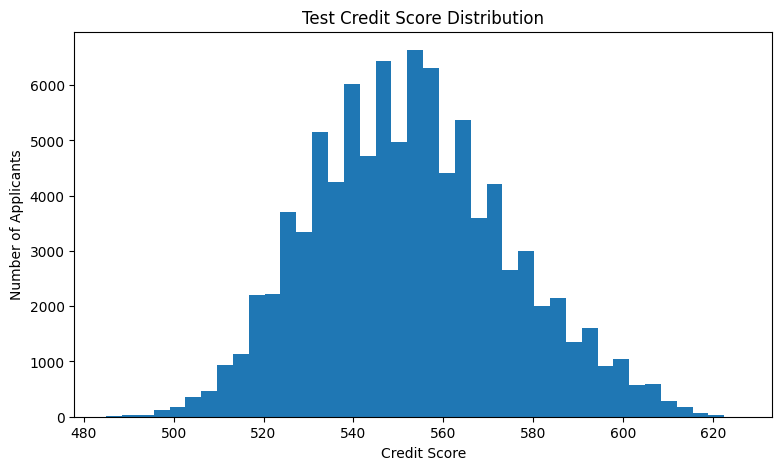

In [96]:
plt.figure(
    figsize=(9, 5)
)

plt.hist(
    test_scores,
    bins=40,
)

plt.xlabel(
    "Credit Score"
)

plt.ylabel(
    "Number of Applicants"
)

plt.title(
    "Test Credit Score Distribution"
)

plt.show()


## 10. Optional linear rescaling to 300–850

This step is **optional** and disabled by default.

The primary score remains the PDO-based score.

If an institution specifically wants a 300–850 presentation range, the already calculated scores can be linearly rescaled.

Note: this presentation rescaling no longer preserves the original PDO interpretation exactly.


In [97]:
TARGET_MIN = 300
TARGET_MAX = 850

APPLY_LINEAR_RESCALE = False

if APPLY_LINEAR_RESCALE:

    observed_min = (
        test_scores.min()
    )

    observed_max = (
        test_scores.max()
    )

    rescale_slope = (
        TARGET_MAX
        - TARGET_MIN
    ) / (
        observed_max
        - observed_min
    )

    rescale_intercept = (
        TARGET_MIN
        - rescale_slope
        * observed_min
    )

    rescaled_scores = (
        test_scores
        * rescale_slope
        + rescale_intercept
    ).round(0).astype(int)

    print(
        "Rescaled score range:",
        f"[{rescaled_scores.min()}, "
        f"{rescaled_scores.max()}]"
    )

else:
    print(
        "Linear rescaling disabled. "
        "PDO-based scores are kept unchanged."
    )


Linear rescaling disabled. PDO-based scores are kept unchanged.


## 11. Score one applicant end-to-end

This final example returns:

- Probability of Default
- Credit Score
- optional statistical Good/Bad class based on the KS threshold

The KS class is only a statistical classification. It is **not** an approval/rejection decision.


In [98]:
sample_applicant = (
    X_test.iloc[[0]]
    .copy()
)

sample_woe = transform_to_woe(
    data=sample_applicant,
    bins=woe_bins,
)

sample_model = select_model_features(
    woe_data=sample_woe,
    selected_features=model_features,
)

sample_score_detail = (
    score_from_woe(
        woe_data=sample_model,
        card_with_woe=card_with_woe,
        basepoints=basepoints,
        only_total_score=False,
    )
)

sample_score = (
    sample_score_detail[
        "score"
    ]
    .iloc[0]
)

sample_pd = (
    lr_model
    .predict_proba(
        sample_model
    )[:, 1][0]
)

print(
    f"Probability of Default : "
    f"{sample_pd:.4f}"
)

print(
    f"Credit Score           : "
    f"{sample_score}"
)

if "ks_threshold" in pipeline:

    ks_threshold = float(
        pipeline[
            "ks_threshold"
        ]
    )

    statistical_class = (
        "Bad"
        if sample_pd
        >= ks_threshold
        else "Good"
    )

    print(
        f"KS threshold           : "
        f"{ks_threshold:.4f}"
    )

    print(
        "Statistical class      : "
        f"{statistical_class}"
    )

print(
    "\nPoints breakdown:"
)

display(
    sample_score_detail
)


[INFO] converting into woe values ...
Probability of Default : 0.0809
Credit Score           : 556
KS threshold           : 0.1101
Statistical class      : Good

Points breakdown:


,score,int_rate_points,loan_burden_interest_points,installment_to_income_ratio_points,tot_cur_bal_points,total_rev_hi_lim_points,loan_to_income_ratio_points,credit_inquiry_rate_points,annual_inc_points,inq_last_6mths_points,term_points,purpose_points,tot_coll_amt_points,credit_history_months_points,revol_util_points,initial_list_status_points,dti_points,verification_status_points,home_ownership_points,addr_state_points,open_account_ratio_points,investor_funding_ratio_points,total_acc_points,emp_length_years_points,revol_bal_points,installment_points,mths_since_last_record_points
0,556,-2.0,7.0,2.0,1.0,-0.0,-2.0,-0.0,-1.0,-8.0,0.0,2.0,3.0,2.0,0.0,3.0,-1.0,0.0,-0.0,-5.0,0.0,0.0,-1.0,1.0,-0.0,0.0,7.0


## 12. Export scorecard artifacts

In [99]:
# Scorecard points with WoE mapping
card_with_woe.to_csv(
    REPORT_DIR
    / "scorecard_points_table.csv",
    index=False,
)

# Scaling parameters
scaling_config = pd.DataFrame({
    "parameter": [
        "score_0",
        "odds_0_good_over_bad",
        "odds_0_scorecardpy_bad_over_good",
        "pdo",
        "factor",
        "offset",
    ],
    "value": [
        SCORE_0,
        ODDS_0_GOOD_OVER_BAD,
        odds0_scorecardpy,
        PDO,
        FACTOR,
        OFFSET,
    ],
})

scaling_config.to_csv(
    REPORT_DIR
    / "scaling_configuration.csv",
    index=False,
)

# Test scores
pd.DataFrame({
    "credit_score": test_scores,
    "predicted_pd": test_pd,
}).to_parquet(
    REPORT_DIR
    / "test_credit_scores.parquet",
    index=False,
)

# Update pipeline with scorecard artifacts.
updated_pipeline = {
    **pipeline,
    "model_features": model_features,
    "scorecard_card": card,
    "scorecard_points0": SCORE_0,
    "scorecard_odds0_good_over_bad": (
        ODDS_0_GOOD_OVER_BAD
    ),
    "scorecard_pdo": PDO,
    "scorecard_factor": FACTOR,
    "scorecard_offset": OFFSET,
}

with open(
    MODEL_DIR
    / "credit_risk_pipeline.pkl",
    "wb",
) as file:
    pickle.dump(
        updated_pipeline,
        file,
    )

print(
    "Scorecard artifacts exported successfully."
)

print(
    "Points table:",
    (
        REPORT_DIR
        / "scorecard_points_table.csv"
    ).resolve(),
)

print(
    "Scaling config:",
    (
        REPORT_DIR
        / "scaling_configuration.csv"
    ).resolve(),
)


Scorecard artifacts exported successfully.
Points table: C:\Users\Platini AGOUANET\Mes Dossiers lourds\risk-credit-scoring-new\reports\pd_scoring\scorecard_points_table.csv
Scaling config: C:\Users\Platini AGOUANET\Mes Dossiers lourds\risk-credit-scoring-new\reports\pd_scoring\scaling_configuration.csv


In [100]:
test_pd.min(), test_pd.max()


(np.float64(0.007767693429061645), np.float64(0.5191860718930166))

## Conclusion

The PD model has now been converted into a points-based credit score.

The final operational chain is:

`Applicant data → WoE → Logistic Regression → PD → Credit Score`

Key validation results:

- higher PD corresponds to lower score;
- the score is almost perfectly negatively related to model log-odds;
- score construction reuses the same validated WoE transformation as the PD model;
- no approval/rejection policy is imposed by this notebook;
- optional 300–850 rescaling remains available only as a presentation choice.

The score is therefore a business-friendly representation of the same underlying PD model.
